In [ ]:
import MDAnalysis as mda
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
from MDAnalysis.analysis.rms import rmsd


In [ ]:
u5 = mda.Universe('initial.gro', 'rep1234.wrapF.xtc')

lig = u5.select_atoms("resname protac")  
rows = []

for ts in u5.trajectory:
    I_tensor = lig.moment_of_inertia(wrap=False, unwrap=False)

    I1, I2, I3 = np.linalg.eigvalsh(I_tensor)

    rows.append({
        "frame": ts.frame,
        "time_ps": ts.time,
        "PMI1": I1,
        "PMI2": I2,
        "PMI3": I3,
        "NPR1": I1 / I3,
        "NPR2": I2 / I3,
    })

df = pd.DataFrame(rows)
df.to_csv("PMI_NPR_trajectory.csv", index=False)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib as mpl


mpl.rcParams.update({
    "font.family": "Arial",      
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.linewidth": 1.1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def classify_pmi_shapes(df, x_col="NPR1", y_col="NPR2"):
    """
    Classify each frame as rod-like, disc-like, or sphere-like
    based on the closest PMI triangle vertex.
    """

    df = df.copy()

    # PMI shape vertices
    rod = np.array([0.0, 1.0])
    disc = np.array([0.5, 0.5])
    sphere = np.array([1.0, 1.0])

    points = df[[x_col, y_col]].values

    df["distance_to_rod"] = np.linalg.norm(points - rod, axis=1)
    df["distance_to_disc"] = np.linalg.norm(points - disc, axis=1)
    df["distance_to_sphere"] = np.linalg.norm(points - sphere, axis=1)

    distance_cols = ["distance_to_rod", "distance_to_disc", "distance_to_sphere"]

    shape_map = {
        "distance_to_rod": "Rod-like",
        "distance_to_disc": "Disc-like / flat",
        "distance_to_sphere": "Sphere-like"
    }

    df["PMI_shape"] = df[distance_cols].idxmin(axis=1).map(shape_map)

    return df


def plot_pmi_triangle_with_percentages(
    df,
    x_col="NPR1",
    y_col="NPR2",
    title="Normalized PMI distribution of PROTAC conformations",
    save_prefix="PMI_triangle_with_percentages"
):

    # Classify frames
    df_plot = classify_pmi_shapes(df, x_col=x_col, y_col=y_col)

    # Percentages
    counts = df_plot["PMI_shape"].value_counts()
    percentages = df_plot["PMI_shape"].value_counts(normalize=True) * 100

    rod_pct = percentages.get("Rod-like", 0.0)
    disc_pct = percentages.get("Disc-like / flat", 0.0)
    sphere_pct = percentages.get("Sphere-like", 0.0)

    n_frames = len(df_plot)

    mean_npr1 = df_plot[x_col].mean()
    mean_npr2 = df_plot[y_col].mean()

    median_npr1 = df_plot[x_col].median()
    median_npr2 = df_plot[y_col].median()

    # Colors
    colors = {
        "Rod-like": "#4C78A8",
        "Disc-like / flat": "#F58518",
        "Sphere-like": "#54A24B"
    }

    # Create figure
    fig, ax = plt.subplots(figsize=(6.4, 5.8))

    # Triangle vertices
    rod = (0.0, 1.0)
    disc = (0.5, 0.5)
    sphere = (1.0, 1.0)

    # Triangle background
    triangle = Polygon(
        [rod, disc, sphere],
        closed=True,
        facecolor="#EEF6FF",
        edgecolor="#333333",
        linewidth=1.25,
        alpha=0.95,
        zorder=1
    )
    ax.add_patch(triangle)

    # Triangle border
    ax.plot([rod[0], disc[0]], [rod[1], disc[1]], color="#333333", lw=1.25, zorder=2)
    ax.plot([disc[0], sphere[0]], [disc[1], sphere[1]], color="#333333", lw=1.25, zorder=2)
    ax.plot([rod[0], sphere[0]], [rod[1], sphere[1]], color="#333333", lw=1.25, zorder=2)

    # Shape guide lines
    for c in [1.15, 1.30, 1.45, 1.60, 1.75]:
        x_start = c - 1.0
        x_end = c / 2.0
        y_start = 1.0
        y_end = x_end

        if 0 <= x_start <= 1 and 0.5 <= x_end <= 1:
            ax.plot(
                [x_start, x_end],
                [y_start, y_end],
                ls=(0, (6, 5)),
                color="#B8B8B8",
                lw=0.9,
                alpha=0.65,
                zorder=2
            )

    # Plot points by class
    for shape in ["Rod-like", "Disc-like / flat", "Sphere-like"]:
        subset = df_plot[df_plot["PMI_shape"] == shape]
        pct = percentages.get(shape, 0.0)

        ax.scatter(
            subset[x_col],
            subset[y_col],
            s=12,
            color=colors[shape],
            alpha=0.55,
            edgecolors="none",
            label=f"{shape}: {pct:.1f}%",
            zorder=3
        )

    # Mean point
    ax.scatter(
        mean_npr1,
        mean_npr2,
        s=90,
        marker="X",
        color="black",
        edgecolors="white",
        linewidths=0.8,
        label="Mean position",
        zorder=5
    )

    # Shape labels
    ax.text(
        0.075, 0.84,
        f"Rod-like\n{rod_pct:.1f}%",
        rotation=-55,
        ha="center",
        va="center",
        fontsize=12,
        color="#222222"
    )

    ax.text(
        0.50, 0.535,
        f"Disc-like / flat\n{disc_pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        color="#222222"
    )

    ax.text(
        0.88, 0.84,
        f"Sphere-like\n{sphere_pct:.1f}%",
        rotation=55,
        ha="center",
        va="center",
        fontsize=12,
        color="#222222"
    )

    # Summary text box
    summary_text = (
        f"Frames: {n_frames}\n"
        f"Mean NPR1: {mean_npr1:.3f}\n"
        f"Mean NPR2: {mean_npr2:.3f}\n"
        f"Median NPR1: {median_npr1:.3f}\n"
        f"Median NPR2: {median_npr2:.3f}"
    )

    ax.text(
        0.03, 0.525,
        summary_text,
        ha="left",
        va="bottom",
        fontsize=9.5,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="#B0B0B0",
            alpha=0.9
        ),
        zorder=6
    )

    # Axis labels
    ax.set_xlabel(r"NPR1 = $I_1/I_3$")
    ax.set_ylabel(r"NPR2 = $I_2/I_3$")
    ax.set_title(title, pad=10)

    # Axis limits
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 1.02)
    ax.set_aspect("equal", adjustable="box")

    # Ticks
    ax.set_xticks(np.arange(0, 1.01, 0.1))
    ax.set_yticks(np.arange(0.5, 1.01, 0.1))

    # Style
    ax.tick_params(direction="out", length=4, width=1)
    ax.grid(False)

    # Legend
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=2,
        frameon=False
    )

    plt.tight_layout()

    # Save files
    plt.savefig(f"{save_prefix}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{save_prefix}.svg", bbox_inches="tight")

    plt.show()

    # Print numerical summary
    print("\nPMI shape classification summary")
    print("--------------------------------")
    print(f"Number of frames: {n_frames}")
    print(f"Rod-like:        {rod_pct:.2f}%")
    print(f"Disc-like/flat:  {disc_pct:.2f}%")
    print(f"Sphere-like:     {sphere_pct:.2f}%")
    print(f"Mean NPR1:       {mean_npr1:.3f}")
    print(f"Mean NPR2:       {mean_npr2:.3f}")
    print(f"Median NPR1:     {median_npr1:.3f}")
    print(f"Median NPR2:     {median_npr2:.3f}")

    # Save dataframe with classifications
    df_plot.to_csv(f"{save_prefix}_classified_frames.csv", index=False)

    return df_plot

In [ ]:
mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.linewidth": 1.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def classify_pmi_shapes(df, x_col="NPR1", y_col="NPR2"):
    """
    Classify each frame as rod-like, disc-like/flat, or sphere-like
    based on the closest normalized PMI triangle vertex.
    """

    df = df.copy()

    rod = np.array([0.0, 1.0])
    disc = np.array([0.5, 0.5])
    sphere = np.array([1.0, 1.0])

    points = df[[x_col, y_col]].values

    df["distance_to_rod"] = np.linalg.norm(points - rod, axis=1)
    df["distance_to_disc"] = np.linalg.norm(points - disc, axis=1)
    df["distance_to_sphere"] = np.linalg.norm(points - sphere, axis=1)

    distance_cols = [
        "distance_to_rod",
        "distance_to_disc",
        "distance_to_sphere"
    ]

    shape_map = {
        "distance_to_rod": "Rod-like",
        "distance_to_disc": "Disc-like / flat",
        "distance_to_sphere": "Sphere-like"
    }

    df["PMI_shape"] = df[distance_cols].idxmin(axis=1).map(shape_map)

    return df


def plot_pmi_triangle_with_percentages(
    df,
    x_col="NPR1",
    y_col="NPR2",
    title="Normalized PMI distribution of PROTAC conformations",
    save_prefix="PMI_triangle_with_percentages"
):
    # ==============================
    # Classify frames
    # ==============================
    df_plot = classify_pmi_shapes(df, x_col=x_col, y_col=y_col)

    # ==============================
    # Calculate percentages
    # ==============================
    percentages = df_plot["PMI_shape"].value_counts(normalize=True) * 100

    rod_pct = percentages.get("Rod-like", 0.0)
    disc_pct = percentages.get("Disc-like / flat", 0.0)
    sphere_pct = percentages.get("Sphere-like", 0.0)

    n_frames = len(df_plot)

    mean_npr1 = df_plot[x_col].mean()
    mean_npr2 = df_plot[y_col].mean()

    median_npr1 = df_plot[x_col].median()
    median_npr2 = df_plot[y_col].median()

    dominant_shape = percentages.idxmax()
    dominant_pct = percentages.max()

    # ==============================
    # Colors
    # ==============================
    colors = {
        "Rod-like": "#3B6EA8",
        "Disc-like / flat": "#E6862E",
        "Sphere-like": "#3C9D5A"
    }

    # ==============================
    # Create figure
    # ==============================
    fig, ax = plt.subplots(figsize=(6.6, 5.9))

    # Triangle vertices
    rod = (0.0, 1.0)
    disc = (0.5, 0.5)
    sphere = (1.0, 1.0)

    # Triangle background
    triangle = Polygon(
        [rod, disc, sphere],
        closed=True,
        facecolor="#EEF6FF",
        edgecolor="#222222",
        linewidth=1.4,
        alpha=0.96,
        zorder=1
    )
    ax.add_patch(triangle)

    # Triangle border
    ax.plot(
        [rod[0], disc[0]],
        [rod[1], disc[1]],
        color="#222222",
        lw=1.4,
        zorder=2
    )

    ax.plot(
        [disc[0], sphere[0]],
        [disc[1], sphere[1]],
        color="#222222",
        lw=1.4,
        zorder=2
    )

    ax.plot(
        [rod[0], sphere[0]],
        [rod[1], sphere[1]],
        color="#222222",
        lw=1.4,
        zorder=2
    )

    # Shape guide lines
    for c in [1.15, 1.30, 1.45, 1.60, 1.75]:
        x_start = c - 1.0
        x_end = c / 2.0
        y_start = 1.0
        y_end = x_end

        if 0 <= x_start <= 1 and 0.5 <= x_end <= 1:
            ax.plot(
                [x_start, x_end],
                [y_start, y_end],
                ls=(0, (6, 5)),
                color="#AFAFAF",
                lw=1.0,
                alpha=0.65,
                zorder=2
            )

    # ==============================
    # Plot points by class
    # ==============================
    for shape in ["Rod-like", "Disc-like / flat", "Sphere-like"]:
        subset = df_plot[df_plot["PMI_shape"] == shape]
        pct = percentages.get(shape, 0.0)

        ax.scatter(
            subset[x_col],
            subset[y_col],
            s=14,
            color=colors[shape],
            alpha=0.62,
            edgecolors="none",
            label=f"{shape}: {pct:.1f}%",
            zorder=3
        )

    # Mean point
    ax.scatter(
        mean_npr1,
        mean_npr2,
        s=110,
        marker="X",
        color="gray",
        edgecolors="white",
        linewidths=1.0,
        label="Mean position",
        zorder=6
    )

    # ==============================
    # Straight bold in-plot text labels
    # ==============================
    text_effect = [
        pe.Stroke(linewidth=3.0, foreground="white"),
        pe.Normal()
    ]

    ax.text(
        0.12, 0.93,
        f"Rod-like\n{rod_pct:.1f}%",
        rotation=0,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="#1F1F1F",
        path_effects=text_effect,
        zorder=7
    )

    ax.text(
        0.50, 0.555,
        f"Disc-like / flat\n{disc_pct:.1f}%",
        rotation=0,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="#1F1F1F",
        path_effects=text_effect,
        zorder=7
    )

    ax.text(
        0.84, 0.93,
        f"Sphere-like\n{sphere_pct:.1f}%",
        rotation=0,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color="#1F1F1F",
        path_effects=text_effect,
        zorder=7
    )

    # ==============================
    # Axis labels and title
    # ==============================
    ax.set_xlabel(
        "NPR1",
        fontsize=14,
        fontweight="bold",
        labelpad=8
    )

    ax.set_ylabel(
        "NPR2",
        fontsize=14,
        fontweight="bold",
        rotation=0,
        labelpad=28
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    # ==============================
    # Axis limits and ticks
    # ==============================
    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 1.02)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks(np.arange(0, 1.01, 0.1))
    ax.set_yticks(np.arange(0.5, 1.01, 0.1))

    # Make tick labels bold and straight
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
        tick.set_rotation(0)

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_rotation(0)

    # Tick style
    ax.tick_params(
        direction="out",
        length=4.5,
        width=1.2,
        colors="#222222"
    )

    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.3)
        spine.set_color("#222222")

    ax.grid(False)

    # ==============================
    # Save and show
    # ==============================
    plt.tight_layout()

    plt.savefig(f"{save_prefix}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{save_prefix}.svg", bbox_inches="tight")

    plt.show()

    # ==============================
    # Print numerical summary
    # ==============================
    print("\nPMI shape classification summary")
    print("--------------------------------")
    print(f"Number of frames: {n_frames}")
    print(f"Rod-like:        {rod_pct:.2f}%")
    print(f"Disc-like/flat:  {disc_pct:.2f}%")
    print(f"Sphere-like:     {sphere_pct:.2f}%")
    print(f"Dominant shape:  {dominant_shape} ({dominant_pct:.2f}%)")
    print(f"Mean NPR1:       {mean_npr1:.3f}")
    print(f"Mean NPR2:       {mean_npr2:.3f}")
    print(f"Median NPR1:     {median_npr1:.3f}")
    print(f"Median NPR2:     {median_npr2:.3f}")

    # Save dataframe with classifications
    df_plot.to_csv(f"{save_prefix}_classified_frames.csv", index=False)

    return df_plot

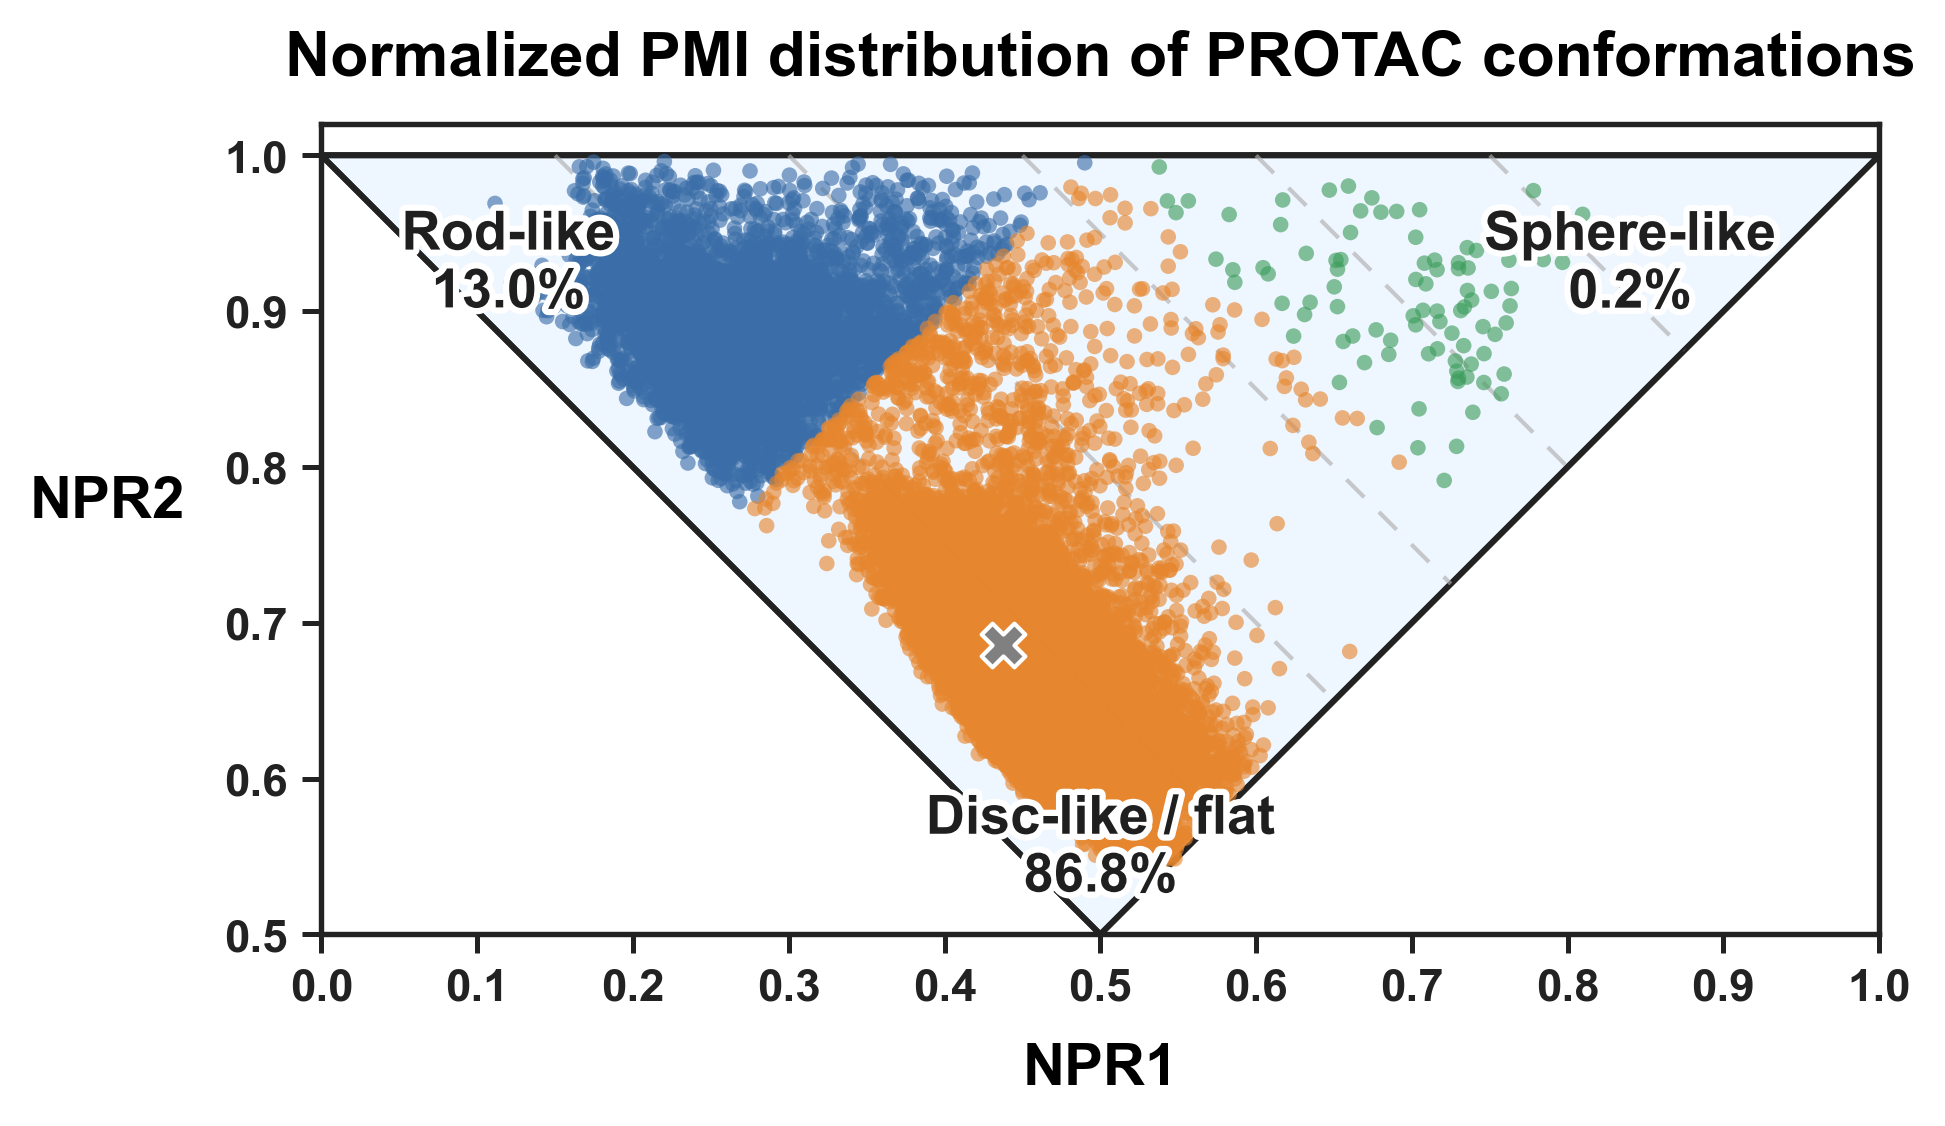


PMI shape classification summary
--------------------------------
Number of frames: 40001
Rod-like:        13.02%
Disc-like/flat:  86.76%
Sphere-like:     0.23%
Dominant shape:  Disc-like / flat (86.76%)
Mean NPR1:       0.437
Mean NPR2:       0.685
Median NPR1:     0.457
Median NPR2:     0.655


In [38]:
df_classified = plot_pmi_triangle_with_percentages(
    df,
    x_col="NPR1",
    y_col="NPR2",
    title="Normalized PMI distribution of PROTAC conformations",
    save_prefix="PROTAC_PMI_triangle"
)

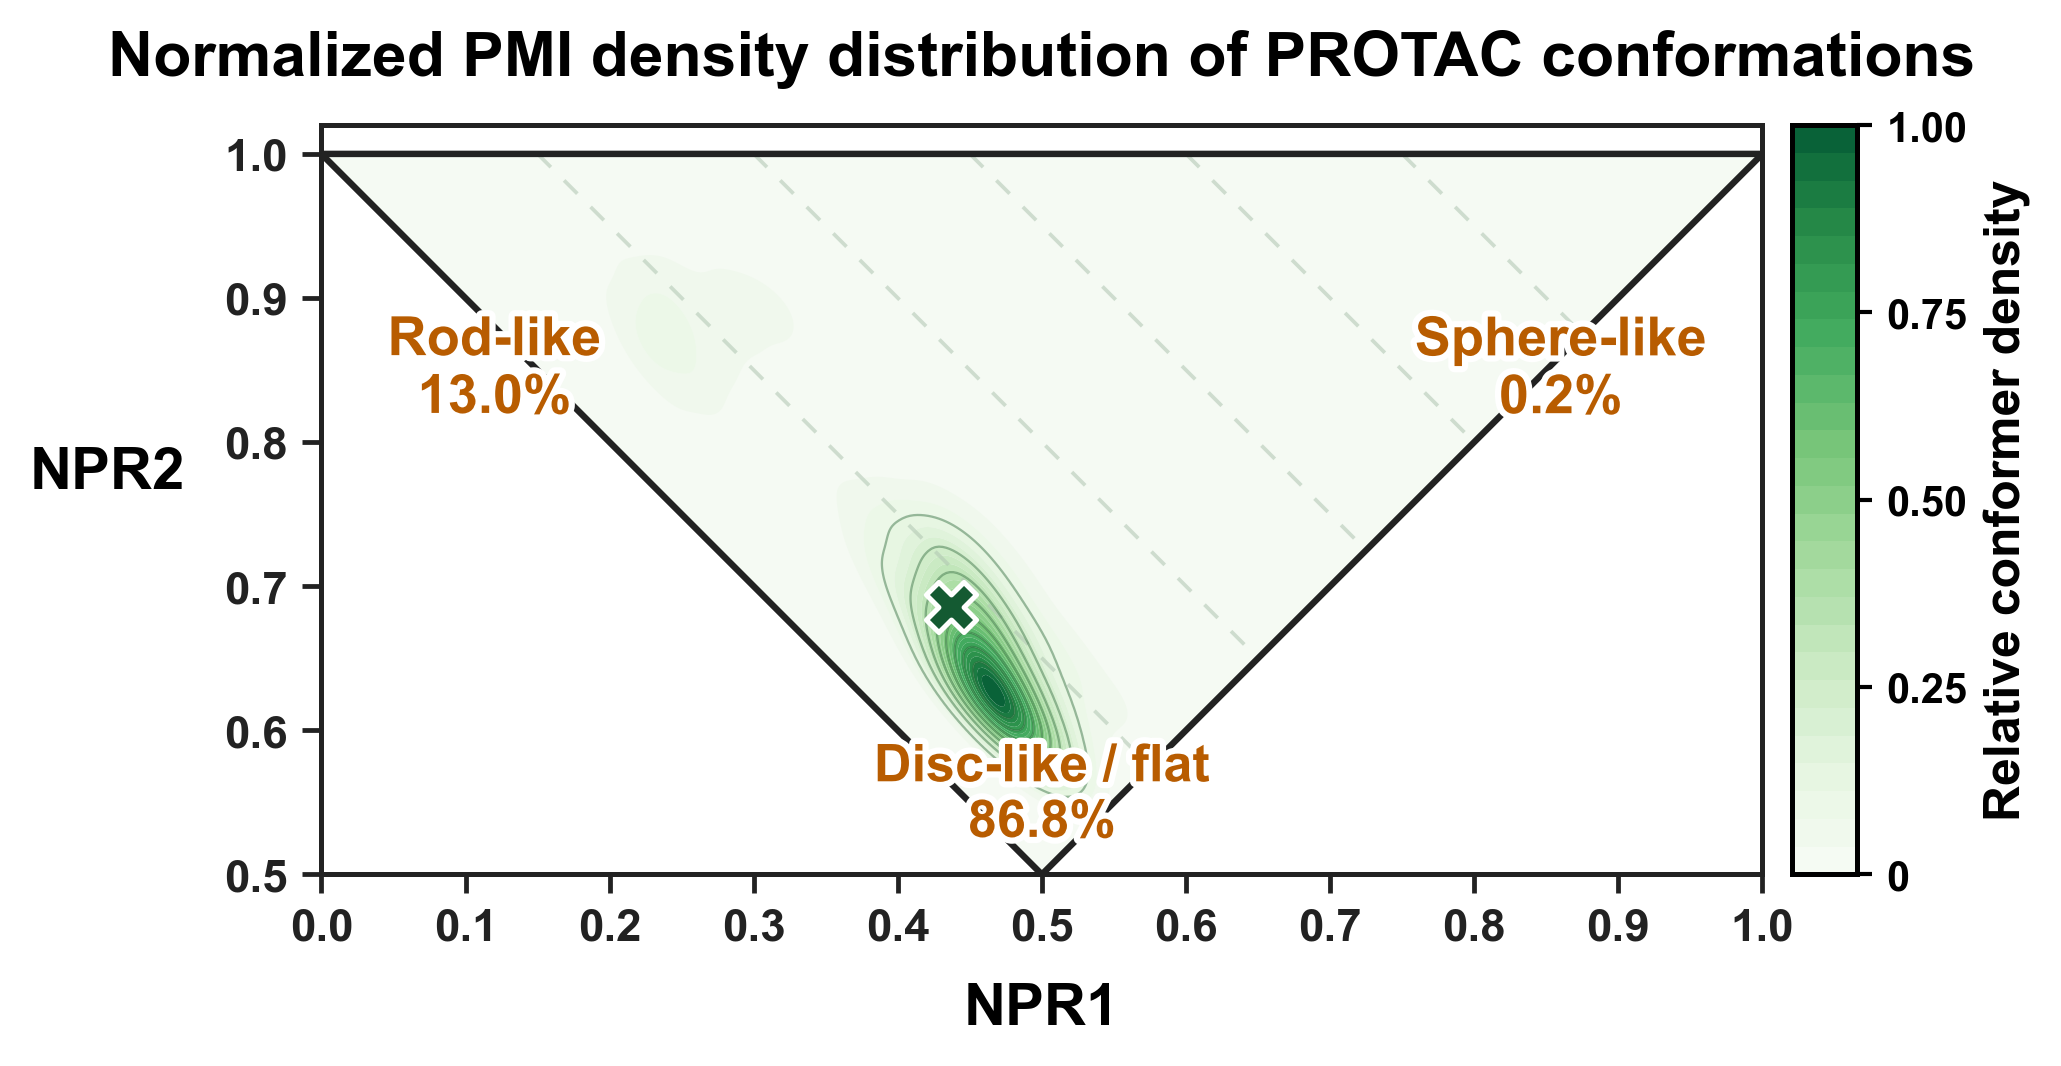


PMI shape classification summary
--------------------------------
Number of frames: 40001
Rod-like:        13.02%
Disc-like/flat:  86.76%
Sphere-like:     0.23%
Dominant shape:  Disc-like / flat (86.76%)
Mean NPR1:       0.437
Mean NPR2:       0.685
Median NPR1:     0.457
Median NPR2:     0.655


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable

mpl.rcParams.update({
    "font.family": ["Arial", "DejaVu Sans"],
    "font.size": 11,
    "font.weight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.linewidth": 1.2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ==============================
# Green colormap
# ==============================
green_cmap = LinearSegmentedColormap.from_list(
    "green_density",
    [
        "#F7FCF5",
        "#E5F5E0",
        "#C7E9C0",
        "#A1D99B",
        "#74C476",
        "#41AB5D",
        "#238B45",
        "#005A32"
    ]
)


def classify_pmi_shapes(df, x_col="NPR1", y_col="NPR2"):
    """
    Classify each frame as rod-like, disc-like/flat, or sphere-like
    based on the closest normalized PMI triangle vertex.
    """

    df = df.copy()

    rod = np.array([0.0, 1.0])
    disc = np.array([0.5, 0.5])
    sphere = np.array([1.0, 1.0])

    points = df[[x_col, y_col]].values

    df["distance_to_rod"] = np.linalg.norm(points - rod, axis=1)
    df["distance_to_disc"] = np.linalg.norm(points - disc, axis=1)
    df["distance_to_sphere"] = np.linalg.norm(points - sphere, axis=1)

    distance_cols = [
        "distance_to_rod",
        "distance_to_disc",
        "distance_to_sphere"
    ]

    shape_map = {
        "distance_to_rod": "Rod-like",
        "distance_to_disc": "Disc-like / flat",
        "distance_to_sphere": "Sphere-like"
    }

    df["PMI_shape"] = df[distance_cols].idxmin(axis=1).map(shape_map)

    return df


def make_pmi_triangle_mask(X, Y):
    """
    Mask for normalized PMI triangle.

    Valid region:
    y >= 0.5 + abs(x - 0.5)
    y <= 1.0
    """

    lower_boundary = 0.5 + np.abs(X - 0.5)

    mask = (
        (X >= 0.0) &
        (X <= 1.0) &
        (Y >= lower_boundary) &
        (Y <= 1.0)
    )

    return mask


def plot_pmi_triangle_with_kde(
    df,
    x_col="NPR1",
    y_col="NPR2",
    title="Normalized PMI density distribution of PROTAC conformations",
    save_prefix="PMI_triangle_KDE_green_relative_density",
    kde_grid_size=400,
    kde_levels=28,
    kde_bw_method=0.18,
    show_mean=True,
    show_colorbar=True
):
  
    # ==============================
    # Prepare data
    # ==============================
    df_plot = classify_pmi_shapes(df, x_col=x_col, y_col=y_col)
    df_plot = df_plot.dropna(subset=[x_col, y_col]).copy()

    percentages = df_plot["PMI_shape"].value_counts(normalize=True) * 100

    rod_pct = percentages.get("Rod-like", 0.0)
    disc_pct = percentages.get("Disc-like / flat", 0.0)
    sphere_pct = percentages.get("Sphere-like", 0.0)

    n_frames = len(df_plot)

    mean_npr1 = df_plot[x_col].mean()
    mean_npr2 = df_plot[y_col].mean()

    median_npr1 = df_plot[x_col].median()
    median_npr2 = df_plot[y_col].median()

    dominant_shape = percentages.idxmax()
    dominant_pct = percentages.max()

    # ==============================
    # Figure
    # ==============================
    fig, ax = plt.subplots(figsize=(7.0, 6.2))
    ax.set_facecolor("white")

    rod = (0.0, 1.0)
    disc = (0.5, 0.5)
    sphere = (1.0, 1.0)

    # Triangle background
    triangle = Polygon(
        [rod, disc, sphere],
        closed=True,
        facecolor="#F5F8F4",
        edgecolor="#222222",
        linewidth=1.5,
        alpha=1.0,
        zorder=1
    )
    ax.add_patch(triangle)

    # ==============================
    # KDE density
    # ==============================
    x = df_plot[x_col].values
    y = df_plot[y_col].values

    if len(df_plot) >= 3:
        values = np.vstack([x, y])

        try:
            kde = gaussian_kde(values, bw_method=kde_bw_method)
        except np.linalg.LinAlgError:
            rng = np.random.default_rng(42)
            x = x + rng.normal(0, 1e-5, size=len(x))
            y = y + rng.normal(0, 1e-5, size=len(y))
            values = np.vstack([x, y])
            kde = gaussian_kde(values, bw_method=kde_bw_method)

        x_grid = np.linspace(0.0, 1.0, kde_grid_size)
        y_grid = np.linspace(0.5, 1.0, kde_grid_size)

        X, Y = np.meshgrid(x_grid, y_grid)

        positions = np.vstack([X.ravel(), Y.ravel()])
        Z = np.reshape(kde(positions), X.shape)

        triangle_mask = make_pmi_triangle_mask(X, Y)
        Z_masked = np.ma.masked_where(~triangle_mask, Z)

        # ==============================
        # Normalize KDE density to 0-1
        # ==============================
        density_max = Z_masked.max()

        if density_max > 0:
            Z_masked = Z_masked / density_max

        levels = np.linspace(0.0, 1.0, kde_levels)

        contourf = ax.contourf(
            X,
            Y,
            Z_masked,
            levels=levels,
            cmap=green_cmap,
            alpha=0.98,
            antialiased=True,
            zorder=2
        )

        ax.contour(
            X,
            Y,
            Z_masked,
            levels=levels[::3],
            colors="#2F6B3B",
            linewidths=0.55,
            alpha=0.45,
            zorder=3
        )

        # ==============================
        # Colorbar same height as plot
        # ==============================
        if show_colorbar:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes(
                "right",
                size="4.5%",
                pad=0.10
            )

            cbar = fig.colorbar(contourf, cax=cax)

            cbar.set_label(
                "Relative conformer density",
                fontsize=12,
                fontweight="bold"
            )

            cbar.set_ticks([0.0, 0.25, 0.50, 0.75, 1.0])
            cbar.set_ticklabels(["0", "0.25", "0.50", "0.75", "1.00"])

            cbar.ax.tick_params(
                labelsize=10,
                width=1.0,
                length=3.5
            )

            for tick in cbar.ax.get_yticklabels():
                tick.set_fontweight("bold")

    else:
        print("Not enough points for KDE. At least 3 points are required.")

    # ==============================
    # Triangle borders
    # ==============================
    ax.plot(
        [rod[0], disc[0]],
        [rod[1], disc[1]],
        color="#222222",
        lw=1.5,
        zorder=4
    )

    ax.plot(
        [disc[0], sphere[0]],
        [disc[1], sphere[1]],
        color="#222222",
        lw=1.5,
        zorder=4
    )

    ax.plot(
        [rod[0], sphere[0]],
        [rod[1], sphere[1]],
        color="#222222",
        lw=1.5,
        zorder=4
    )

    # ==============================
    # Shape guide lines
    # ==============================
    for c in [1.15, 1.30, 1.45, 1.60, 1.75]:
        x_start = c - 1.0
        x_end = c / 2.0
        y_start = 1.0
        y_end = x_end

        if 0 <= x_start <= 1 and 0.5 <= x_end <= 1:
            ax.plot(
                [x_start, x_end],
                [y_start, y_end],
                ls=(0, (5, 5)),
                color="#AFC5B1",
                lw=0.9,
                alpha=0.55,
                zorder=2
            )

    # ==============================
    # Mean point without legend
    # ==============================
    if show_mean:
        ax.scatter(
            mean_npr1,
            mean_npr2,
            s=145,
            marker="X",
            color="#145A32",
            edgecolors="white",
            linewidths=1.2,
            zorder=6
        )

    # ==============================
    # Text labels
    # ==============================
    text_effect = [
        pe.Stroke(linewidth=3.0, foreground="white"),
        pe.Normal()
    ]

    label_color = "#B85C00"

    ax.text(
        0.12,
        0.85,
        f"Rod-like\n{rod_pct:.1f}%",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=label_color,
        path_effects=text_effect,
        zorder=7
    )

    ax.text(
        0.50,
        0.555,
        f"Disc-like / flat\n{disc_pct:.1f}%",
        ha="center",
        va="center",
        fontsize=12.5,
        fontweight="bold",
        color=label_color,
        path_effects=text_effect,
        zorder=7
    )

    ax.text(
        0.86,
        0.85,
        f"Sphere-like\n{sphere_pct:.1f}%",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold",
        color=label_color,
        path_effects=text_effect,
        zorder=7
    )

    # ==============================
    # Axes
    # ==============================
    ax.set_xlabel(
        "NPR1",
        fontsize=14,
        fontweight="bold",
        labelpad=8
    )

    ax.set_ylabel(
        "NPR2",
        fontsize=14,
        fontweight="bold",
        rotation=0,
        labelpad=28
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=12
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0.5, 1.02)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xticks(np.arange(0, 1.01, 0.1))
    ax.set_yticks(np.arange(0.5, 1.01, 0.1))

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
        tick.set_rotation(0)

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_rotation(0)

    ax.tick_params(
        direction="out",
        length=4.5,
        width=1.15,
        colors="#222222"
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color("#222222")

    ax.grid(False)

    # ==============================
    # Save and show
    # ==============================
    plt.tight_layout()

    plt.savefig(f"{save_prefix}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
    plt.savefig(f"{save_prefix}.svg", bbox_inches="tight")

    plt.show()

    # ==============================
    # Print summary
    # ==============================
    print("\nPMI shape classification summary")
    print("--------------------------------")
    print(f"Number of frames: {n_frames}")
    print(f"Rod-like:        {rod_pct:.2f}%")
    print(f"Disc-like/flat:  {disc_pct:.2f}%")
    print(f"Sphere-like:     {sphere_pct:.2f}%")
    print(f"Dominant shape:  {dominant_shape} ({dominant_pct:.2f}%)")
    print(f"Mean NPR1:       {mean_npr1:.3f}")
    print(f"Mean NPR2:       {mean_npr2:.3f}")
    print(f"Median NPR1:     {median_npr1:.3f}")
    print(f"Median NPR2:     {median_npr2:.3f}")

    df_plot.to_csv(
        f"{save_prefix}_classified_frames.csv",
        index=False
    )

    return df_plot


df_classified = plot_pmi_triangle_with_kde(
    df,
    x_col="NPR1",
    y_col="NPR2",
    title="Normalized PMI density distribution of PROTAC conformations",
    save_prefix="PROTAC_PMI_KDE_green_relative_density",
    kde_grid_size=400,
    kde_levels=28,
    kde_bw_method=0.18,
    show_mean=True,
    show_colorbar=True
)